# Part 1: Imitation Learning & Why It Breaks
### From Behavioral Cloning to RLHF — A Practitioner's Guide to Deep RL

**Series:** [github.com/your-username/from-bc-to-rlhf](https://github.com/)  
**Part 1 of 8** · Next → [Part 2: Policy Gradients](../02-policy-gradients/notebook.ipynb)

---

### What You'll Learn

1. **What is an MDP?** — The framework behind all of reinforcement learning
2. **Behavioral Cloning** — The simplest way to learn from an expert (it's just supervised learning)
3. **Distribution Shift** — Why this simple approach has a fatal flaw
4. **DAgger** — A practical fix that introduces interactive learning
5. **The LLM Connection** — How this all maps to how ChatGPT is trained

### Prerequisites

You should be comfortable with:
- Python and PyTorch basics (tensors, `nn.Module`, training loops)
- Supervised learning concepts (loss functions, gradient descent, overfitting)

No prior RL knowledge needed — we start from scratch.

### References
- 📺 [CS285 Lecture 2: Supervised Learning of Behaviors](https://www.youtube.com/playlist?list=PL_iWQOsE6TfVYGEGiAOMaOzzv41Jfm_Ps) — Sergey Levine, UC Berkeley
- 📄 [Ross et al. (2011) — DAgger paper](https://arxiv.org/abs/1011.0686)

> **Time estimate:** ~3 hours to run the full notebook

---
## Setup

In [1]:
!pip install gymnasium[classic_control] gymnasium[box2d] torch numpy matplotlib tqdm -q

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device} | PyTorch: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 66.0 MB/s eta 0:00:00
Device: cuda | PyTorch: 2.10.0+cu128


---
## 1. What Is an MDP?

Before we can talk about learning, we need a framework for **sequential decision-making**. That framework is the **Markov Decision Process (MDP)**.

An MDP has five components:

| Component | Symbol | Meaning | Example (CartPole) |
|-----------|--------|---------|--------------------|
| States | $\mathcal{S}$ | What the agent observes | Cart position, velocity, pole angle, angular velocity |
| Actions | $\mathcal{A}$ | What the agent can do | Push left (0) or push right (1) |
| Transitions | $P(s'\|s,a)$ | How the world changes | Physics simulation |
| Rewards | $r(s,a)$ | Feedback signal | +1 for each step the pole stays upright |
| Discount | $\gamma$ | How much we value future vs present | Typically 0.99 |

A **policy** $\pi(a|s)$ tells the agent what action to take in each state. The goal of RL is to find the best policy — the one that maximizes total reward over time.

**The "Markov" part:** The next state depends only on the current state and action, not on the full history. This makes the problem tractable.

> 📖 *For a deeper treatment: [Sutton & Barto, Ch. 3](http://incompleteideas.net/book/the-book-2nd.html)*

Let's look at a real MDP:

In [3]:
def explore_environment(env_name):
    """Inspect the MDP structure of a Gymnasium environment."""
    env = gym.make(env_name)
    print(f"\n{'='*50}")
    print(f"  {env_name}")
    print(f"{'='*50}")
    print(f"  States:  {env.observation_space} (shape: {env.observation_space.shape})")
    print(f"  Actions: {env.action_space}", end="")
    if hasattr(env.action_space, 'n'):
        print(f" → {env.action_space.n} discrete choices")

    obs, _ = env.reset(seed=SEED)
    print(f"\n  Sample trajectory (random policy):")
    for step in range(3):
        action = env.action_space.sample()
        next_obs, reward, done, _, _ = env.step(action)
        print(f"    t={step}: state={obs[:3].round(3)}... → action={action} → reward={reward:.1f} → next_state={next_obs[:3].round(3)}...")
        obs = next_obs
        if done: break
    env.close()

explore_environment('CartPole-v1')
explore_environment('LunarLander-v3')


  CartPole-v1
  States:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32) (shape: (4,))
  Actions: Discrete(2) → 2 discrete choices

  Sample trajectory (random policy):
    t=0: state=[ 0.027 -0.006  0.036]... → action=1 → reward=1.0 → next_state=[0.027 0.188 0.036]...
    t=1: state=[0.027 0.188 0.036]... → action=1 → reward=1.0 → next_state=[0.031 0.383 0.031]...
    t=2: state=[0.031 0.383 0.031]... → action=0 → reward=1.0 → next_state=[0.039 0.188 0.02 ]...

  LunarLander-v3
  States:  Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32) (shape: (8,))
  Actions: Discrete(4) → 4 discrete choices

  Sample trajectory (random policy):
    t=0: state=[0.002 1.418 0.233]... → action=3 → reward=0.5 → next_state=[0.005 1.425 0.24 ]...
    t=1: state=[0.005 1.425 0.24 ]... → acti

Notice the pattern: at each step, the agent sees a **state**, picks an **action**, gets a **reward**, and lands in a **next state**. This loop is the foundation of everything in RL.

---
## 2. Behavioral Cloning — Learning by Imitation

### The Idea

Suppose we have an **expert** that already knows how to solve the task. Can we just copy its behavior?

**Behavioral Cloning (BC)** does exactly this:
1. Watch the expert act → collect a dataset of (state, action) pairs
2. Train a neural network to predict the expert's action from the state

That's it. It's **supervised learning** — the same thing you'd do for image classification, except the inputs are states and the labels are actions.

**Loss function:**
$$\mathcal{L}(\theta) = -\mathbb{E}_{(s,a^*) \sim \mathcal{D}} \left[ \log \pi_\theta(a^* | s) \right]$$

This is just **cross-entropy loss** — maximize the probability the network assigns to the expert's action.

> 💡 **LLM connection:** Supervised Fine-Tuning (SFT) — the first stage of training ChatGPT — is exactly behavioral cloning. The "expert" is human-written responses, and the "state" is the prompt.

### Step 1: Create an Expert

In [4]:
class CartPoleExpert:
    """
    Hand-crafted expert for CartPole-v1.
    Uses a simple rule: push in the direction the pole is falling.
    Achieves perfect score (500/500).
    """
    def predict(self, obs):
        pole_angle = obs[2]
        pole_velocity = obs[3]
        return 1 if pole_angle + 0.25 * pole_velocity > 0 else 0


def evaluate_policy(policy_fn, env_name, n_episodes=20, max_steps=500):
    """Run a policy for n episodes and return mean/std reward."""
    env = gym.make(env_name)
    rewards = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=SEED + ep)
        total = 0
        for _ in range(max_steps):
            obs, r, done, trunc, _ = env.step(policy_fn(obs))
            total += r
            if done or trunc: break
        rewards.append(total)
    env.close()
    return np.mean(rewards), np.std(rewards)


expert = CartPoleExpert()
mean_r, std_r = evaluate_policy(expert.predict, 'CartPole-v1')
print(f"Expert performance: {mean_r:.0f} ± {std_r:.0f} (max possible: 500)")

Expert performance: 500 ± 0 (max possible: 500)


### Step 2: Collect Expert Demonstrations

In [5]:
def collect_demonstrations(expert_fn, env_name, n_episodes, max_steps=500):
    """Watch the expert and record (state, action) pairs."""
    env = gym.make(env_name)
    states, actions = [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=SEED + ep)
        for _ in range(max_steps):
            action = expert_fn(obs)
            states.append(obs.copy())
            actions.append(action)
            obs, _, done, trunc, _ = env.step(action)
            if done or trunc: break
    env.close()
    return np.array(states, dtype=np.float32), np.array(actions, dtype=np.int64)


states, actions = collect_demonstrations(expert.predict, 'CartPole-v1', n_episodes=25)
print(f"Collected {len(states)} (state, action) pairs from 25 expert episodes")
print(f"Action distribution: {np.bincount(actions)}  (0=left, 1=right)")

Collected 12500 (state, action) pairs from 25 expert episodes
Action distribution: [6252 6248]  (0=left, 1=right)


### Step 3: Define a Policy Network

A simple 2-layer MLP that takes a state and outputs logits over actions. This is our learnable policy $\pi_\theta(a|s)$.

In [6]:
class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim),
        )

    def forward(self, x):
        return self.net(x)  # returns logits

    def get_action(self, obs):
        with torch.no_grad():
            logits = self.forward(torch.FloatTensor(obs).unsqueeze(0).to(device))
            return logits.argmax(dim=-1).item()


policy = PolicyNetwork(obs_dim=4, act_dim=2).to(device)
print(f"Policy network: {sum(p.numel() for p in policy.parameters()):,} parameters")

Policy network: 4,610 parameters


### Step 4: Train via Behavioral Cloning

In [7]:
def train_bc(states, actions, obs_dim, act_dim, hidden=64, lr=1e-3,
             n_epochs=100, batch_size=64, eval_env='CartPole-v1', eval_every=20):
    """Train a policy via behavioral cloning (supervised learning)."""
    policy = PolicyNetwork(obs_dim, act_dim, hidden).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    dataset = TensorDataset(
        torch.FloatTensor(states).to(device),
        torch.LongTensor(actions).to(device)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    history = {'loss': [], 'eval_reward': []}

    for epoch in range(n_epochs):
        policy.train()
        losses = []
        for s_batch, a_batch in loader:
            loss = loss_fn(policy(s_batch), a_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        history['loss'].append(np.mean(losses))

        if (epoch + 1) % eval_every == 0:
            policy.eval()
            mean_r, std_r = evaluate_policy(policy.get_action, eval_env)
            history['eval_reward'].append(mean_r)
            print(f"  Epoch {epoch+1:3d} | Loss: {history['loss'][-1]:.4f} | Reward: {mean_r:.0f} ± {std_r:.0f}")

    return policy, history


print("Training behavioral cloning on 25 expert episodes...")
bc_policy, bc_history = train_bc(states, actions, obs_dim=4, act_dim=2)

Training behavioral cloning on 25 expert episodes...
  Epoch  20 | Loss: 0.1135 | Reward: 500 ± 0
  Epoch  40 | Loss: 0.0782 | Reward: 500 ± 0
  Epoch  60 | Loss: 0.0565 | Reward: 500 ± 0
  Epoch  80 | Loss: 0.0462 | Reward: 500 ± 0
  Epoch 100 | Loss: 0.0465 | Reward: 500 ± 0


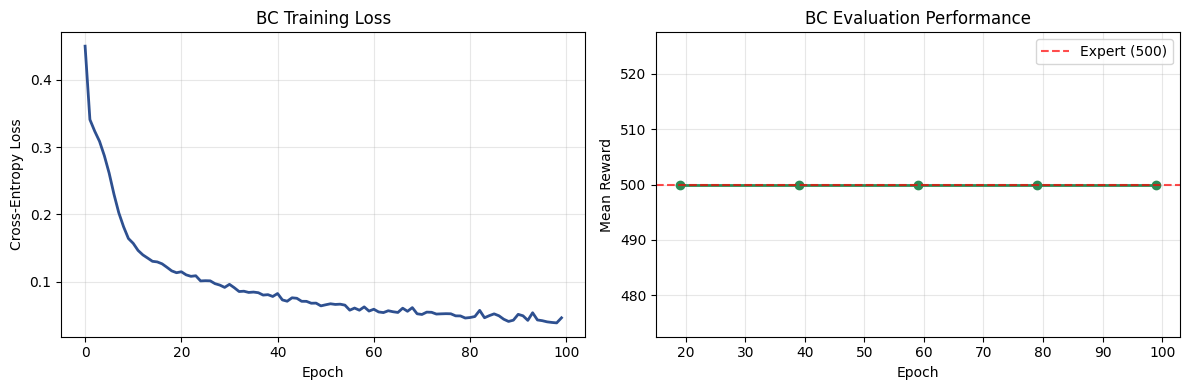

In [8]:
# Visualize training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bc_history['loss'], color='#2E5090', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('BC Training Loss'); axes[0].grid(True, alpha=0.3)

eval_epochs = list(range(19, 100, 20))
axes[1].plot(eval_epochs, bc_history['eval_reward'], color='#2D8B55', linewidth=2, marker='o')
axes[1].axhline(y=500, color='red', linestyle='--', alpha=0.7, label='Expert (500)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean Reward')
axes[1].set_title('BC Evaluation Performance'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

BC gets decent performance — but is it matching the expert? And will it always work this well?

---
## 3. Distribution Shift — The Fatal Flaw of Behavioral Cloning

### The Problem

BC trains on states the **expert** visits. But at test time, the **learned policy** makes slightly different decisions, visiting slightly different states — which it has never seen in training.

A small error per step **compounds**:

$$\text{Total error} \propto \epsilon T^2$$

where $\epsilon$ is the per-step error rate and $T$ is the episode length.

### Intuition: Learning to Drive

Imagine learning to drive by watching videos of an expert:
- The expert always drives in the center of the lane → you learn: "when centered → go straight"
- A small error drifts you to the edge → **you've never seen this situation!**
- You don't know how to recover → you drift further → crash

The training data (center-of-lane states) doesn't cover the test distribution (edge-of-lane states). This is **distribution shift**.

> 📖 *Formal treatment: [Ross & Bagnell (2010)](https://arxiv.org/abs/1011.0686), Section 2*

Let's visualize this directly:

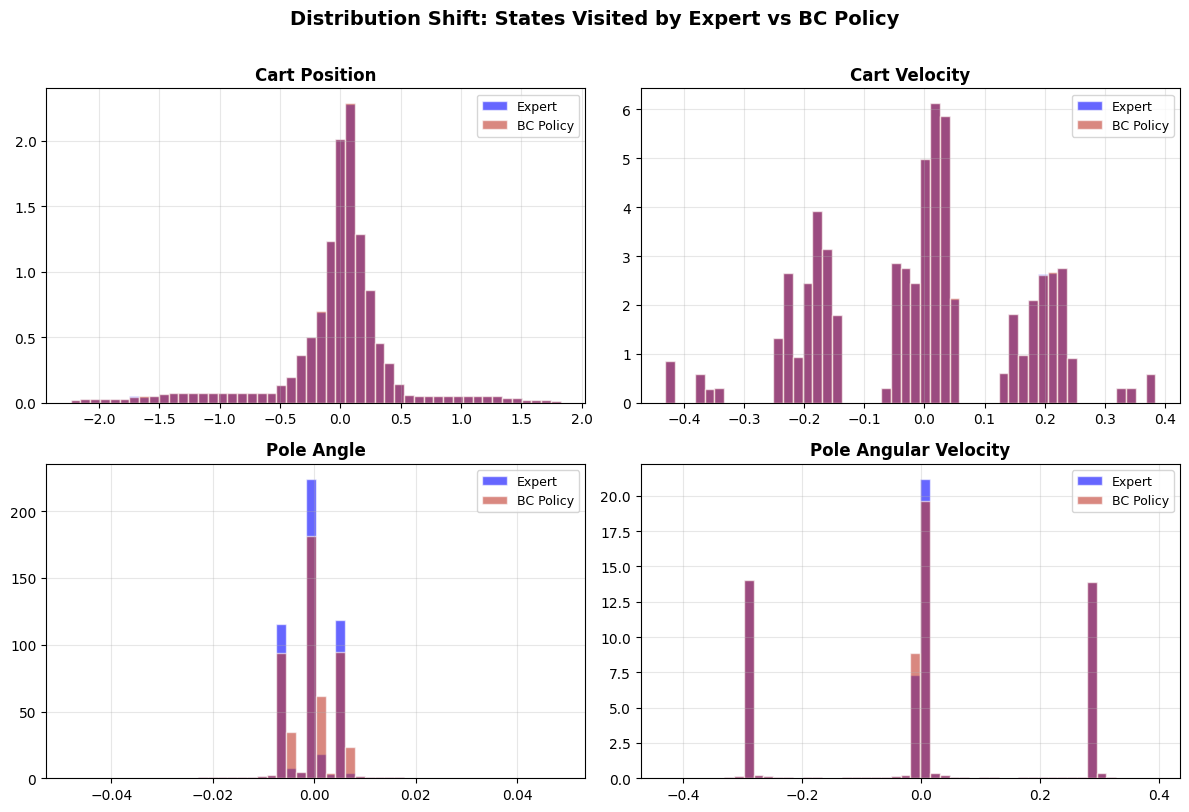

Expert states: 25,000 (stays alive longer → more data)
BC states:     25,000 (may fail earlier → less data)

Notice: BC visits more extreme pole angles the expert never demonstrated.


In [10]:
def collect_state_distribution(policy_fn, env_name, n_episodes=50, max_steps=500):
    """Collect the states a policy actually visits."""
    env = gym.make(env_name)
    all_states = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=SEED + ep)
        for _ in range(max_steps):
            all_states.append(obs.copy())
            obs, _, done, trunc, _ = env.step(policy_fn(obs))
            if done or trunc: break
    env.close()
    return np.array(all_states)


expert_states = collect_state_distribution(expert.predict, 'CartPole-v1')
bc_states = collect_state_distribution(bc_policy.get_action, 'CartPole-v1')

# Plot the distribution shift
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
names = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Angular Velocity']

for i, (ax, name) in enumerate(zip(axes.flat, names)):
    ax.hist(expert_states[:, i], bins=50, alpha=0.6, color='blue',
            label='Expert', density=True, edgecolor='white')
    ax.hist(bc_states[:, i], bins=50, alpha=0.6, color='#C0392B',
            label='BC Policy', density=True, edgecolor='white')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Distribution Shift: States Visited by Expert vs BC Policy',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Expert states: {len(expert_states):,} (stays alive longer → more data)")
print(f"BC states:     {len(bc_states):,} (may fail earlier → less data)")
print(f"\nNotice: BC visits more extreme pole angles the expert never demonstrated.")

### Does More Data Fix This?

Let's check — train BC with increasing amounts of expert data:

   50 episodes (25000 transitions) → 500 ± 0


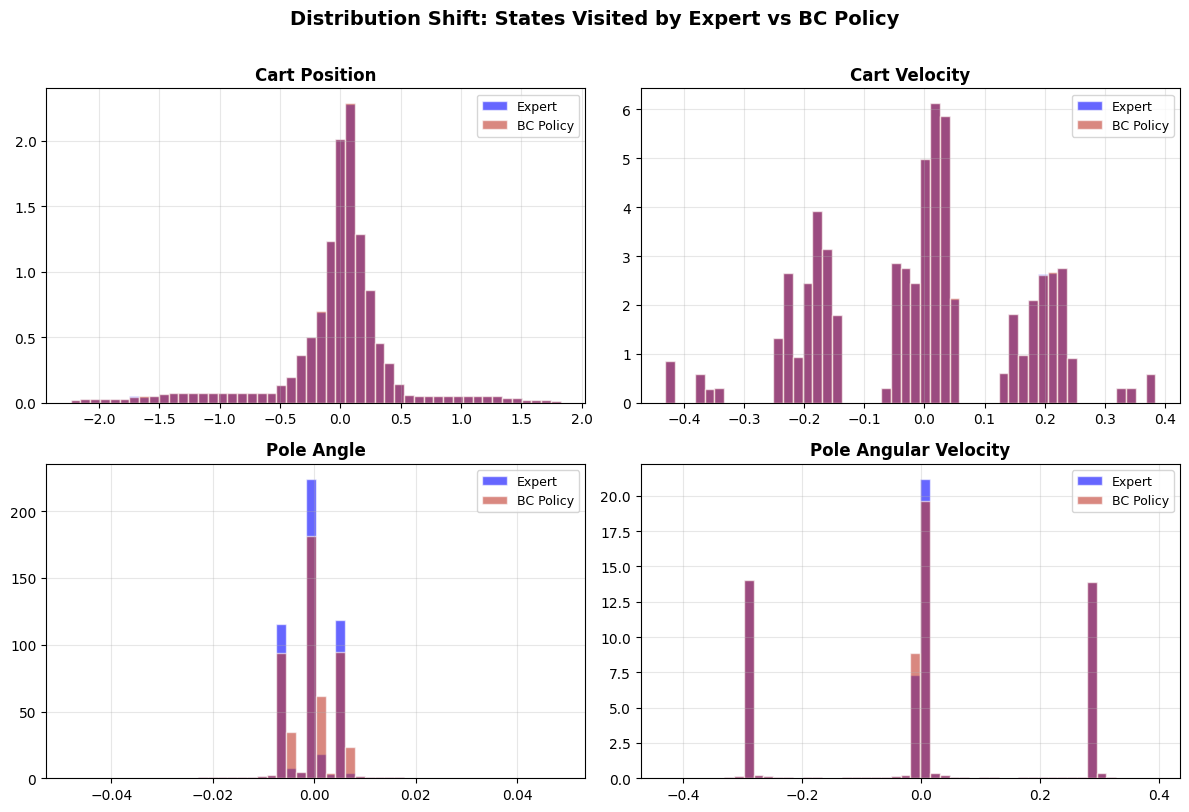

  100 episodes (50000 transitions) → 500 ± 0


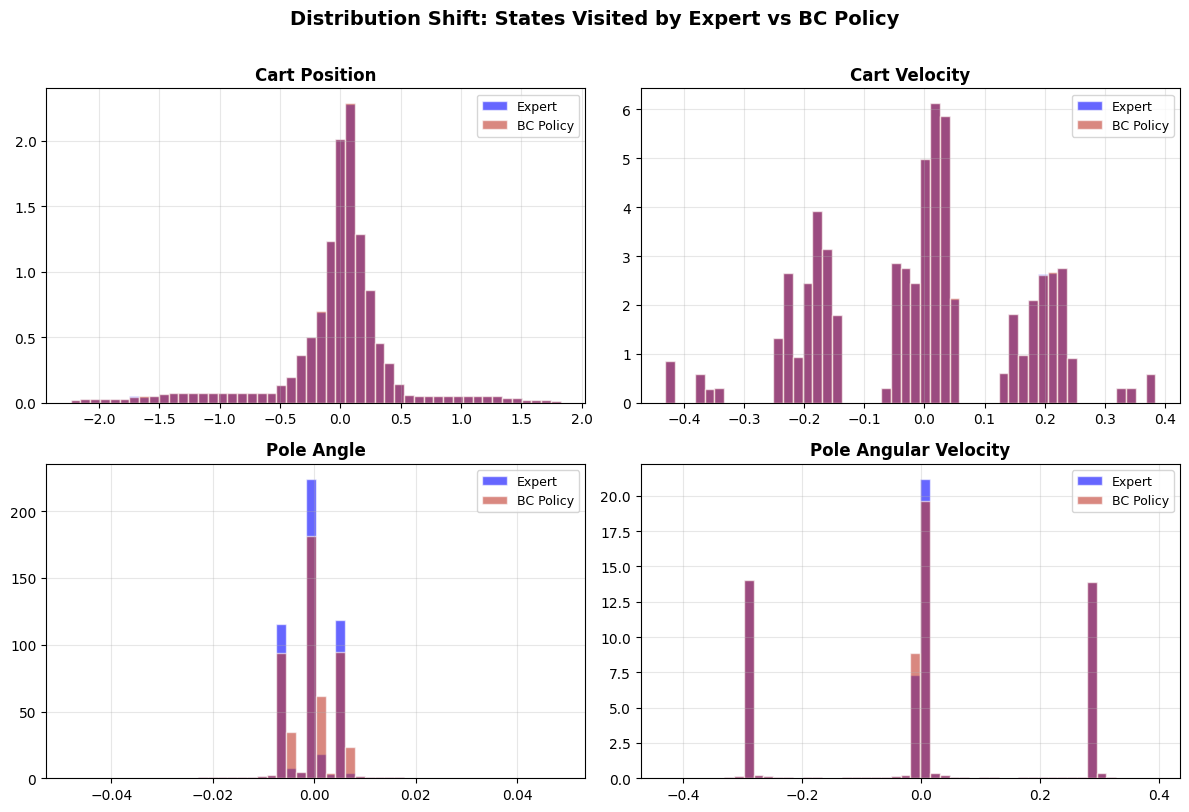

In [12]:
dataset_sizes = [50, 100]
bc_results = []

expert_states = collect_state_distribution(expert.predict, 'CartPole-v1')

for n in dataset_sizes:
    s, a = collect_demonstrations(expert.predict, 'CartPole-v1', n_episodes=n)
    p, _ = train_bc(s, a, 4, 2, n_epochs=100, eval_every=999)  # silent training
    mean_r, std_r = evaluate_policy(p.get_action, 'CartPole-v1', n_episodes=30)
    bc_results.append((n, len(s), mean_r, std_r))
    print(f"  {n:3d} episodes ({len(s):5d} transitions) → {mean_r:.0f} ± {std_r:.0f}")

    bc_states = collect_state_distribution(bc_policy.get_action, 'CartPole-v1')

    # Plot the distribution shift
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    names = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Angular Velocity']

    for i, (ax, name) in enumerate(zip(axes.flat, names)):
        ax.hist(expert_states[:, i], bins=50, alpha=0.6, color='blue',
                label='Expert', density=True, edgecolor='white')
        ax.hist(bc_states[:, i], bins=50, alpha=0.6, color='#C0392B',
                label='BC Policy', density=True, edgecolor='white')
        ax.set_title(name, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    fig.suptitle('Distribution Shift: States Visited by Expert vs BC Policy',
                fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

More data helps, but we can't fully close the gap. The core problem remains: **BC never trains on the states its own policy visits.**

---
## 4. DAgger — Fixing Distribution Shift

**DAgger** (Dataset Aggregation, [Ross et al. 2011](https://arxiv.org/abs/1011.0686)) directly addresses the problem:

```
1. Train initial policy π on expert data D
2. Repeat:
   a. Run π in the environment → collect states it visits
   b. Ask the expert: "what would YOU do in these states?"
   c. Add these new (state, expert_action) pairs to D
   d. Retrain π on the full aggregated dataset D
```

**Why it works:** In step 2a, we collect states from the **learned policy's** distribution. The expert labels these states in 2b. Over iterations, the dataset covers both the expert's states AND the learner's states — closing the distribution gap.

**Theoretical guarantee:** DAgger achieves error linear in $T$ (vs quadratic for BC).

**The catch:** We need to query the expert at every iteration. For LLMs, the "expert" is human labelers — expensive! This cost is exactly what motivates RLHF (Part 7) and DPO (Part 8).

In [13]:
def train_dagger(expert_fn, env_name, obs_dim, act_dim,
                  n_initial_episodes=5, n_iterations=10,
                  n_rollout_episodes=5, max_steps=500,
                  n_train_epochs=50, hidden=64, lr=1e-3, batch_size=64):
    """
    DAgger: Dataset Aggregation.

    Key idea: roll out the LEARNED policy, but label states with the EXPERT.
    This covers the learned policy's state distribution.
    """
    env = gym.make(env_name)

    # Step 1: Collect initial expert data
    all_states, all_actions = [], []
    for ep in range(n_initial_episodes):
        obs, _ = env.reset(seed=SEED + ep)
        for _ in range(max_steps):
            action = expert_fn(obs)
            all_states.append(obs.copy())
            all_actions.append(action)
            obs, _, done, trunc, _ = env.step(action)
            if done or trunc: break

    policy = PolicyNetwork(obs_dim, act_dim, hidden).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    history = {'iteration': [], 'dataset_size': [], 'reward_mean': [], 'reward_std': []}

    for it in range(n_iterations + 1):
        # Train on aggregated dataset
        dataset = TensorDataset(
            torch.FloatTensor(np.array(all_states)).to(device),
            torch.LongTensor(np.array(all_actions)).to(device)
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        policy.train()
        for _ in range(n_train_epochs):
            for s_b, a_b in loader:
                loss = loss_fn(policy(s_b), a_b)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Evaluate
        policy.eval()
        mean_r, std_r = evaluate_policy(policy.get_action, env_name)
        history['iteration'].append(it)
        history['dataset_size'].append(len(all_states))
        history['reward_mean'].append(mean_r)
        history['reward_std'].append(std_r)

        tag = "BC init" if it == 0 else f"DAgger-{it}"
        print(f"  [{tag:10s}] Data: {len(all_states):5d} | Reward: {mean_r:.0f} ± {std_r:.0f}")

        # DAgger: collect from learned policy, label with expert
        if it < n_iterations:
            for ep in range(n_rollout_episodes):
                obs, _ = env.reset(seed=SEED + 1000 + it * 100 + ep)
                for _ in range(max_steps):
                    learned_action = policy.get_action(obs)   # Act with learned policy
                    expert_action = expert_fn(obs)             # Label with expert
                    all_states.append(obs.copy())
                    all_actions.append(expert_action)          # Store expert's label!
                    obs, _, done, trunc, _ = env.step(learned_action)
                    if done or trunc: break

    env.close()
    return policy, history


print("Training DAgger (5 initial episodes + 10 iterations)...")
dagger_policy, dagger_hist = train_dagger(
    expert.predict, 'CartPole-v1', obs_dim=4, act_dim=2
)

Training DAgger (5 initial episodes + 10 iterations)...
  [BC init   ] Data:  2500 | Reward: 500 ± 0
  [DAgger-1  ] Data:  5000 | Reward: 500 ± 0
  [DAgger-2  ] Data:  7500 | Reward: 500 ± 0
  [DAgger-3  ] Data: 10000 | Reward: 500 ± 0
  [DAgger-4  ] Data: 12500 | Reward: 500 ± 0
  [DAgger-5  ] Data: 15000 | Reward: 500 ± 0
  [DAgger-6  ] Data: 17500 | Reward: 500 ± 0
  [DAgger-7  ] Data: 20000 | Reward: 500 ± 0
  [DAgger-8  ] Data: 22500 | Reward: 500 ± 0
  [DAgger-9  ] Data: 25000 | Reward: 500 ± 0
  [DAgger-10 ] Data: 27500 | Reward: 500 ± 0


---
## 5. BC vs DAgger — Head-to-Head

In [14]:
# Train BC with the same amount of data DAgger used (fair comparison)
total_data = dagger_hist['dataset_size'][-1]
fair_episodes = total_data // 500 + 1
s_fair, a_fair = collect_demonstrations(expert.predict, 'CartPole-v1', n_episodes=fair_episodes)
bc_fair, _ = train_bc(s_fair, a_fair, 4, 2, n_epochs=100, eval_every=999)
bc_mean, bc_std = evaluate_policy(bc_fair.get_action, 'CartPole-v1', n_episodes=30)

print(f"\n{'='*50}")
print(f"  Fair comparison ({total_data} transitions each):")
print(f"  Expert:  500 ± 0")
print(f"  BC:      {bc_mean:.0f} ± {bc_std:.0f}")
print(f"  DAgger:  {dagger_hist['reward_mean'][-1]:.0f} ± {dagger_hist['reward_std'][-1]:.0f}")
print(f"{'='*50}")


  Fair comparison (27500 transitions each):
  Expert:  500 ± 0
  BC:      500 ± 0
  DAgger:  500 ± 0


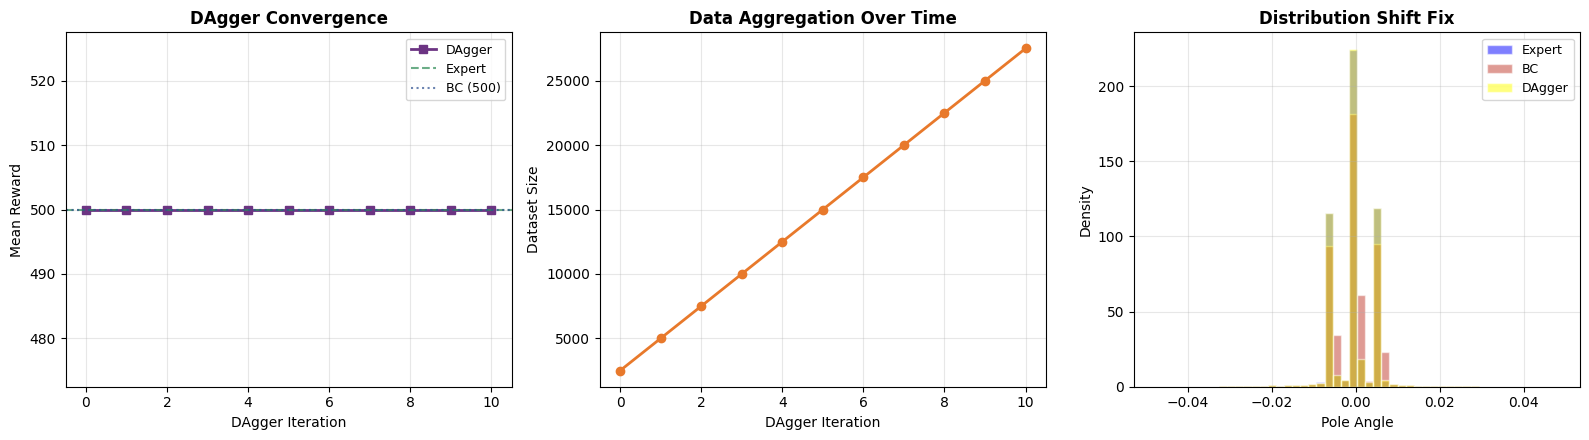

In [17]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. DAgger learning curve
axes[0].plot(dagger_hist['iteration'], dagger_hist['reward_mean'],
             color='#6C3483', linewidth=2, marker='s', label='DAgger')
axes[0].fill_between(dagger_hist['iteration'],
    [m-s for m,s in zip(dagger_hist['reward_mean'], dagger_hist['reward_std'])],
    [m+s for m,s in zip(dagger_hist['reward_mean'], dagger_hist['reward_std'])],
    alpha=0.15, color='#6C3483')
axes[0].axhline(y=500, color='#2D8B55', linestyle='--', alpha=0.7, label='Expert')
axes[0].axhline(y=bc_mean, color='#2E5090', linestyle=':', alpha=0.7, label=f'BC ({bc_mean:.0f})')
axes[0].set_xlabel('DAgger Iteration'); axes[0].set_ylabel('Mean Reward')
axes[0].set_title('DAgger Convergence', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# 2. Dataset growth
axes[1].plot(dagger_hist['iteration'], dagger_hist['dataset_size'],
             color='#E8792B', linewidth=2, marker='o')
axes[1].set_xlabel('DAgger Iteration'); axes[1].set_ylabel('Dataset Size')
axes[1].set_title('Data Aggregation Over Time', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. State coverage (pole angle)
dagger_states = collect_state_distribution(dagger_policy.get_action, 'CartPole-v1')
axes[2].hist(expert_states[:, 2], bins=50, alpha=0.5, color='blue',
             label='Expert', density=True, edgecolor='white')
axes[2].hist(bc_states[:, 2], bins=50, alpha=0.5, color='#C0392B',
             label='BC', density=True, edgecolor='white')
axes[2].hist(dagger_states[:, 2], bins=50, alpha=0.5, color='yellow',
             label='DAgger', density=True, edgecolor='white')
axes[2].set_xlabel('Pole Angle'); axes[2].set_ylabel('Density')
axes[2].set_title('Distribution Shift Fix', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Bonus: LunarLander (Harder Environment)

CartPole is relatively easy. Let's test on **LunarLander-v2** (8D state, 4 actions) using a PPO-trained expert — a preview of the algorithm we'll build ourselves in Part 5.

In [ ]:
!pip install stable-baselines3 -q
from stable_baselines3 import PPO

print("Training PPO expert for LunarLander (~2 min)...")
lunar_expert = PPO('MlpPolicy', 'LunarLander-v2', learning_rate=3e-4,
                   n_steps=1024, batch_size=64, n_epochs=4,
                   gamma=0.999, gae_lambda=0.98, verbose=0, seed=SEED)
lunar_expert.learn(total_timesteps=200_000)

def lunar_predict(obs):
    action, _ = lunar_expert.predict(obs, deterministic=True)
    return int(action)

exp_mean, exp_std = evaluate_policy(lunar_predict, 'LunarLander-v2')
print(f"Expert: {exp_mean:.0f} ± {exp_std:.0f} (good landing ≈ 200+)")

In [ ]:
# BC on LunarLander
l_states, l_actions = collect_demonstrations(lunar_predict, 'LunarLander-v2', n_episodes=50, max_steps=1000)
print("\nBC on LunarLander:")
lunar_bc, _ = train_bc(l_states, l_actions, 8, 4, hidden=128,
                       n_epochs=200, eval_every=50, eval_env='LunarLander-v2')

# DAgger on LunarLander
print("\nDAgger on LunarLander:")
lunar_dagger, lunar_dagger_hist = train_dagger(
    lunar_predict, 'LunarLander-v2', obs_dim=8, act_dim=4,
    n_initial_episodes=10, n_iterations=15,
    n_rollout_episodes=5, max_steps=1000,
    n_train_epochs=50, hidden=128
)

bc_final = evaluate_policy(lunar_bc.get_action, 'LunarLander-v2', n_episodes=30)
dag_final = evaluate_policy(lunar_dagger.get_action, 'LunarLander-v2', n_episodes=30)
print(f"\n{'='*45}")
print(f"  LunarLander Results:")
print(f"  Expert:  {exp_mean:.0f} | BC: {bc_final[0]:.0f} | DAgger: {dag_final[0]:.0f}")
print(f"{'='*45}")

In [ ]:
# LunarLander comparison plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lunar_dagger_hist['iteration'], lunar_dagger_hist['reward_mean'],
        color='#6C3483', linewidth=2.5, marker='s', markersize=6, label='DAgger')
ax.fill_between(lunar_dagger_hist['iteration'],
    [m-s for m,s in zip(lunar_dagger_hist['reward_mean'], lunar_dagger_hist['reward_std'])],
    [m+s for m,s in zip(lunar_dagger_hist['reward_mean'], lunar_dagger_hist['reward_std'])],
    alpha=0.15, color='#6C3483')
ax.axhline(y=exp_mean, color='#2D8B55', linestyle='--', linewidth=2, label=f'Expert ({exp_mean:.0f})')
ax.axhline(y=bc_final[0], color='#2E5090', linestyle=':', linewidth=2, label=f'BC ({bc_final[0]:.0f})')
ax.set_xlabel('DAgger Iteration', fontsize=12)
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('LunarLander: DAgger Progressively Closes the Gap', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### What We Built

| Algorithm | Core Idea | Limitation |
|-----------|-----------|------------|
| **Behavioral Cloning** | Supervised learning on expert (state, action) pairs | Distribution shift — policy visits unseen states |
| **DAgger** | Aggregate data from the learned policy, labeled by expert | Needs to query the expert at every iteration |

### The Big Insight: BC = SFT

Everything in this notebook maps directly to how LLMs are trained:

| Imitation Learning | LLM Training |
|---|---|
| Behavioral Cloning | Supervised Fine-Tuning (SFT) |
| Expert demonstrations | Human-written responses |
| Distribution shift | Model generates tokens it never saw in training |
| DAgger (interactive labeling) | Online RLHF (collect feedback on model's own outputs) |
| Expert query cost | Human labeler cost ($1+ per comparison) |

This is why SFT alone isn't enough for LLMs, and why the field moved to RLHF (Part 7).

### What's Next

Both BC and DAgger require an **expert**. But what if we don't have one — just a reward signal?

**[Part 2: Policy Gradients →](../02-policy-gradients/notebook.ipynb)** introduces the foundational algorithm of RL: learn to maximize reward directly, no expert needed.

---

### Quick Self-Check

Can you explain:
- What is an MDP? Name its 5 components.
- Why does BC fail even with lots of data?
- How does DAgger fix distribution shift?
- Why is DAgger expensive for LLMs?

### References

- 📺 [CS285 Lecture 2](https://www.youtube.com/playlist?list=PL_iWQOsE6TfVYGEGiAOMaOzzv41Jfm_Ps) — Supervised Learning of Behaviors
- 📄 [Ross et al. (2011)](https://arxiv.org/abs/1011.0686) — DAgger paper
- 📘 [Sutton & Barto, Ch. 3](http://incompleteideas.net/book/the-book-2nd.html) — MDP foundations
- 📄 [Ouyang et al. (2022)](https://arxiv.org/abs/2203.02155) — InstructGPT (RLHF = the fix for SFT's distribution shift)

---

*Part 1 of the [From BC to RLHF](https://github.com/your-username/from-bc-to-rlhf) series · [⭐ Star on GitHub](https://github.com/your-username/from-bc-to-rlhf)*